# RecSys Debiasing — Results Analysis
Set `RUN_DIR` and `CACHE_DIR` below, then run all cells.

In [1]:
import os
import pickle
import json
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Configure paths here ──────────────────────────────────────────────────────
RUN_DIR   = "../results/run_main/2026-04-30_16-03-08"   # path to one timestamped run
CACHE_DIR = "../data/ml-1m/cache"                        # where pkl caches live
WINDOW    = 30                                           # trend window used in this run
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

METHOD_COLORS = {
    "gru4rec_ce":           "#4C72B0",
    "gru4rec_ips":          "#DD8452",
    "gru4rec_personalized": "#55A868",
    "popularity":           "#C44E52",
}
DEFAULT_COLOR = "#8172B2"

print(f"Run dir : {os.path.abspath(RUN_DIR)}")
print(f"Cache   : {os.path.abspath(CACHE_DIR)}")

Run dir : c:\Users\rajcr\Desktop\Study\MTech\Courses\RecSys\Project\source_code\recsys_debiasing_gpu\results\run_main\2026-04-30_16-03-08
Cache   : c:\Users\rajcr\Desktop\Study\MTech\Courses\RecSys\Project\source_code\recsys_debiasing_gpu\data\ml-1m\cache


---
## 1 · Training Convergence

In [2]:
# Load train_log.csv for every method subfolder that has one
logs = {}
for entry in sorted(os.listdir(RUN_DIR)):
    log_path = os.path.join(RUN_DIR, entry, "train_log.csv")
    if os.path.isfile(log_path):
        logs[entry] = pd.read_csv(log_path)

print("Methods with training logs:", list(logs.keys()))
if logs:
    first = next(iter(logs.values()))
    print("Columns:", list(first.columns))
    display(first.head(3))

Methods with training logs: ['gru4rec_ce', 'gru4rec_ips', 'gru4rec_personalized']
Columns: ['epoch', 'train_loss', 'lr', 'epoch_time_sec', 'val_recall@10', 'val_ndcg@10']


,epoch,train_loss,lr,epoch_time_sec,val_recall@10,val_ndcg@10
0,1,6.939731,0.0005,20.4,0.069771,0.035125
1,2,6.513221,0.0005,20.4,0.099768,0.050892
2,3,6.326957,0.0005,20.4,0.111535,0.057460


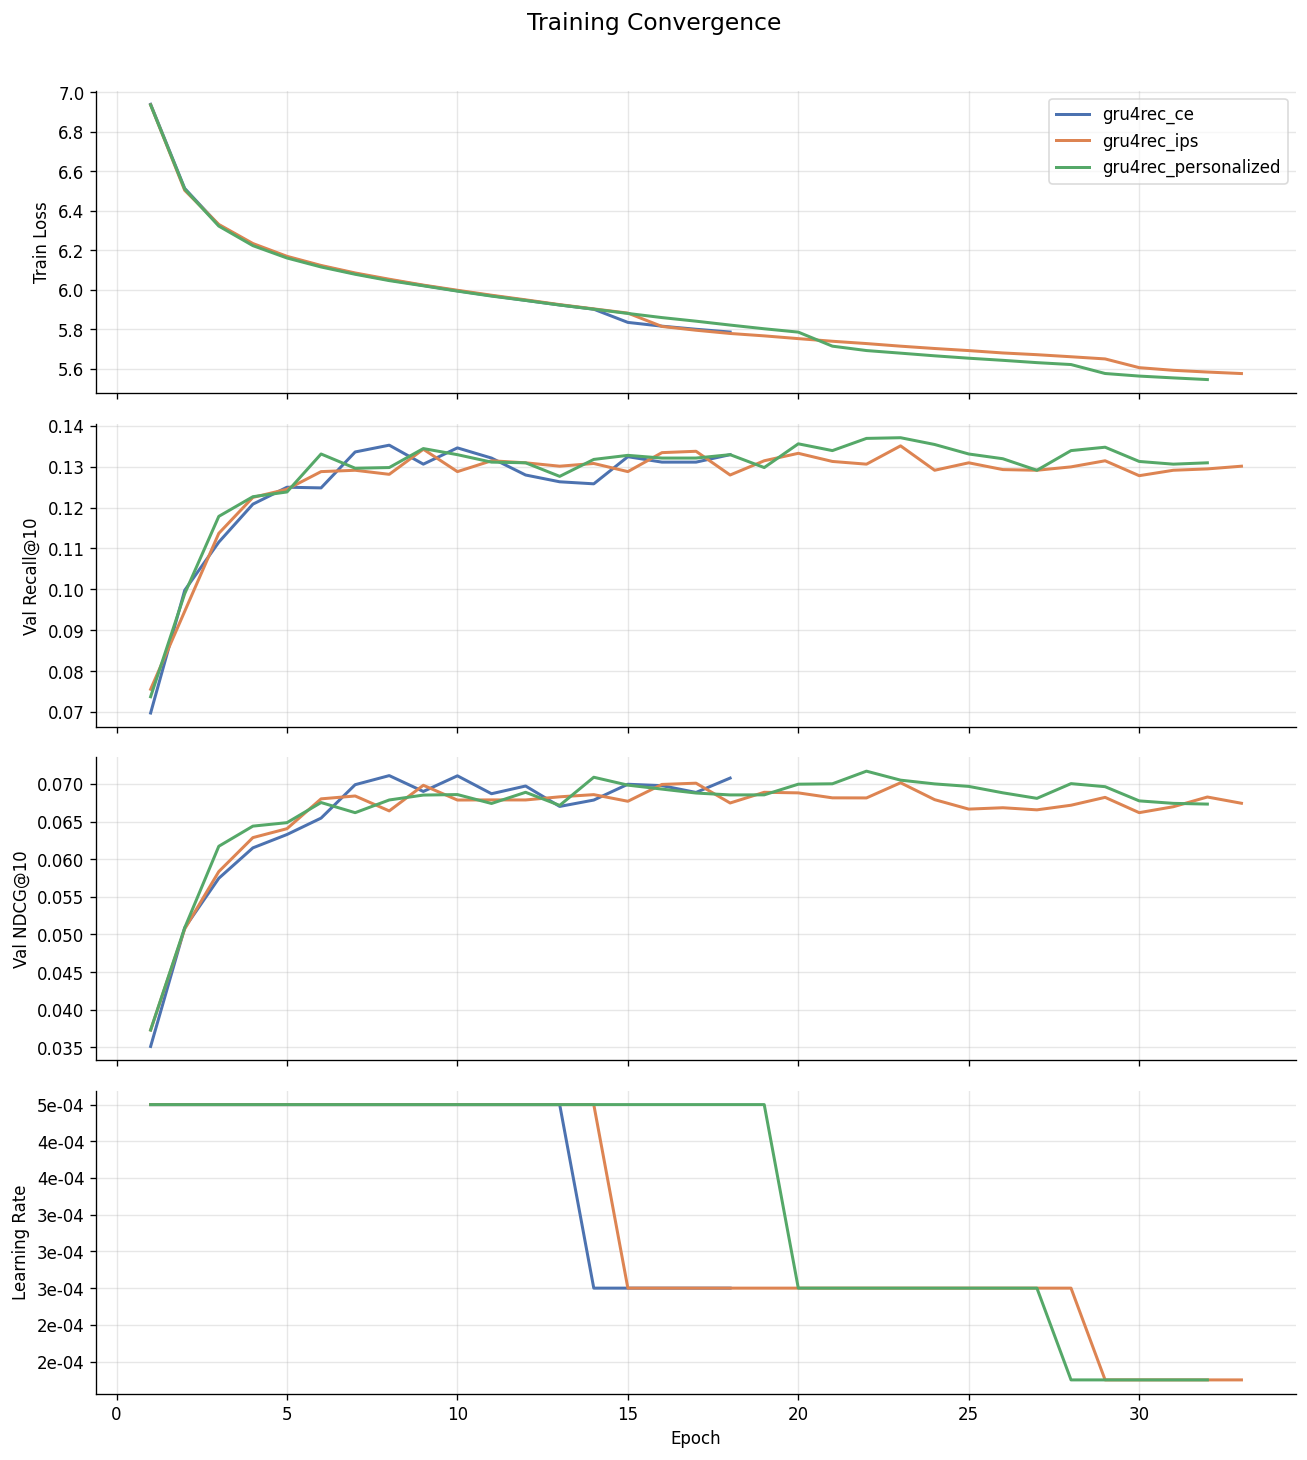

In [3]:
# Decide which metrics to plot (guard against missing grad_norm in old runs)
all_cols = set(col for df in logs.values() for col in df.columns)

METRICS = []
for col, label in [
    ("train_loss",    "Train Loss"),
    ("grad_norm",     "Grad Norm (avg)"),
    ("val_recall@10", "Val Recall@10"),
    ("val_ndcg@10",   "Val NDCG@10"),
    ("lr",            "Learning Rate"),
]:
    if col in all_cols:
        METRICS.append((col, label))

n = len(METRICS)
fig, axes = plt.subplots(n, 1, figsize=(11, 3 * n), sharex=True)
if n == 1:
    axes = [axes]

for method, df in logs.items():
    color = METHOD_COLORS.get(method, DEFAULT_COLOR)
    for ax, (col, label) in zip(axes, METRICS):
        if col in df.columns:
            ax.plot(df["epoch"], df[col], label=method, color=color, linewidth=1.8)

for ax, (col, label) in zip(axes, METRICS):
    ax.set_ylabel(label)
    if col == "lr":
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0e"))

axes[-1].set_xlabel("Epoch")
axes[0].legend(loc="upper right", framealpha=0.7)
fig.suptitle("Training Convergence", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 2 · Model Comparison

In [8]:
summary_path = os.path.join(RUN_DIR, "comparison_summary.csv")

if os.path.isfile(summary_path):
    summary = pd.read_csv(summary_path).set_index("method")
else:
    # Build from individual final_metrics.json files if summary is missing
    rows = {}
    for entry in sorted(os.listdir(RUN_DIR)):
        p = os.path.join(RUN_DIR, entry, "final_metrics.json")
        if os.path.isfile(p):
            with open(p) as f:
                rows[entry] = json.load(f)
    summary = pd.DataFrame(rows).T
    summary.index.name = "method"

print("Final test metrics:")

# Highlight best value per column (higher is better for accuracy; lower for delta_gap)
lower_better  = [c for c in summary.columns if c.startswith("delta_gap")]
lower_better += ["avg_popularity"]
higher_better = [c for c in summary.columns if c not in lower_better]


styled = summary.style.format("{:.4f}")
if higher_better:
    styled = styled.highlight_max(subset=higher_better, color="#c30010")
if lower_better:
    styled = styled.highlight_min(subset=lower_better,  color="#c30010")
display(styled)

Final test metrics:


,recall@10,ndcg@10,delta_gap_niche,delta_gap_diverse,delta_gap_blockbuster,avg_popularity,coverage,long_tail_ratio
method,,,,,,,,
gru4rec_ce,0.1251,0.0645,0.0008,0.0005,0.0007,0.0019,0.4925,0.0929
gru4rec_ips,0.1245,0.0636,0.0007,0.0004,0.0006,0.0019,0.5851,0.1163
gru4rec_personalized,0.1235,0.0626,0.0008,0.0004,0.0006,0.0019,0.5856,0.1165
popularity,0.0414,0.0193,0.0029,0.0024,0.0020,0.0038,0.0326,0.0000


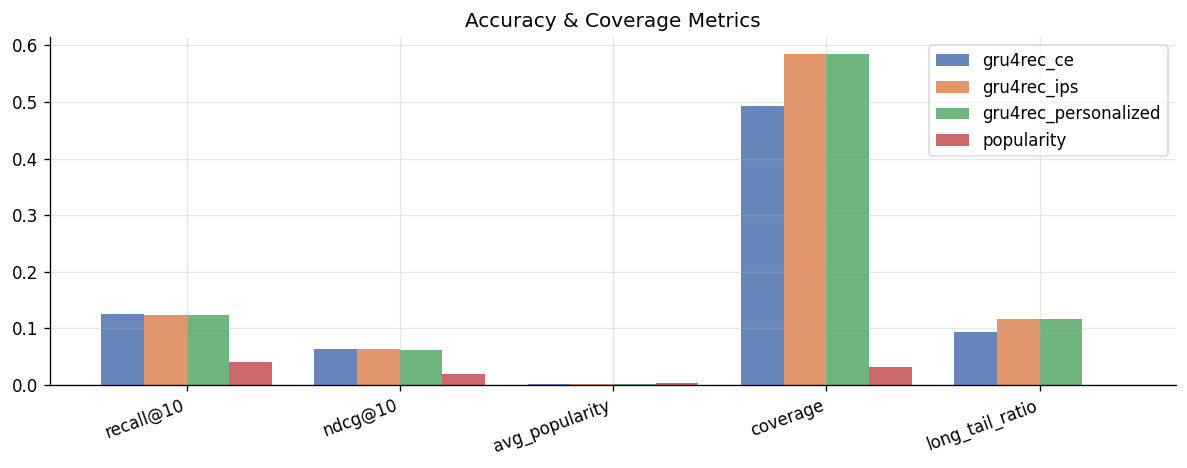

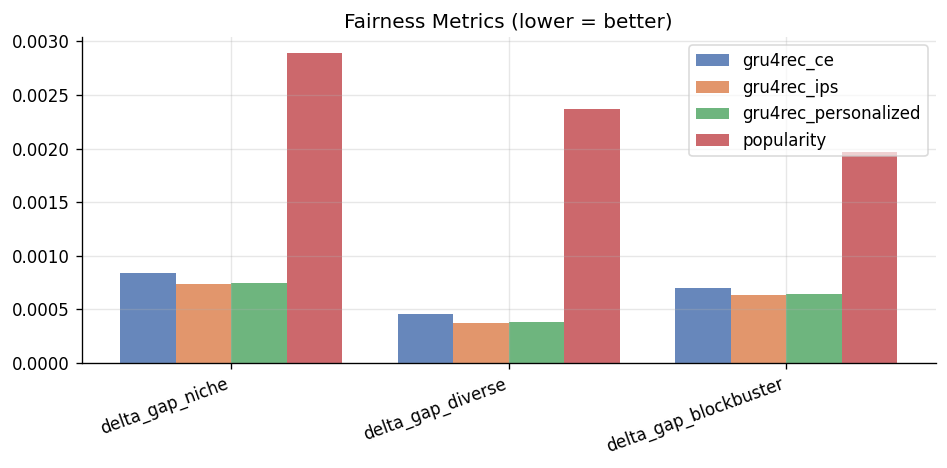

In [9]:
# Bar chart — accuracy and fairness split
ACC_COLS      = [c for c in summary.columns if c in ("recall@10", "ndcg@10", "coverage", "long_tail_ratio", "avg_popularity")]
FAIRNESS_COLS = [c for c in summary.columns if c.startswith("delta_gap")]

for group, cols, title in [
    ("accuracy", ACC_COLS, "Accuracy & Coverage Metrics"),
    ("fairness", FAIRNESS_COLS, "Fairness Metrics (lower = better)"),
]:
    if not cols:
        continue
    sub = summary[cols]
    fig, ax = plt.subplots(figsize=(max(8, len(cols) * 2), 4))
    x = np.arange(len(cols))
    width = 0.8 / len(sub)
    for i, (method, row) in enumerate(sub.iterrows()):
        color = METHOD_COLORS.get(method, DEFAULT_COLOR)
        bars = ax.bar(x + i * width, row.values, width, label=method, color=color, alpha=0.85)
    ax.set_xticks(x + width * (len(sub) - 1) / 2)
    ax.set_xticklabels(cols, rotation=20, ha="right")
    ax.set_title(title)
    ax.legend(loc="upper right", framealpha=0.7)
    plt.tight_layout()
    plt.show()

---
## 3 · Feature Distribution Statistics

In [10]:
def _stats(values, name):
    a = np.array(values, dtype=float)
    return {
        "feature": name,
        "n":       len(a),
        "mean":    a.mean(),
        "std":     a.std(),
        "min":     a.min(),
        "median":  np.median(a),
        "max":     a.max(),
    }

feature_values = {}   # name -> flat np.array for histograms
stat_rows = []

# ── Alpha & Beta ─────────────────────────────────────────────────────────────
identity_path = os.path.join(CACHE_DIR, "identity_formula.pkl")
if os.path.isfile(identity_path):
    with open(identity_path, "rb") as f:
        id_scores = pickle.load(f)   # {user_idx: (alpha, beta)}
    alphas = np.array([v[0] for v in id_scores.values()])
    betas  = np.array([v[1] for v in id_scores.values()])
    feature_values["alpha"] = alphas
    feature_values["beta"]  = betas
    stat_rows += [_stats(alphas, "alpha (per user)"),
                  _stats(betas,  "beta (per user)")]
    print(f"Loaded identity scores: {len(id_scores)} users")
else:
    print(f"[WARN] Not found: {identity_path}")

# ── e_pop ─────────────────────────────────────────────────────────────────────
pop_path = os.path.join(CACHE_DIR, "e_pop.pkl")
if os.path.isfile(pop_path):
    with open(pop_path, "rb") as f:
        e_pop = pickle.load(f)   # {item_idx: float}
    pop_vals = np.array(list(e_pop.values()))
    feature_values["e_pop"] = pop_vals
    stat_rows.append(_stats(pop_vals, "e_pop (per item)"))
    print(f"Loaded e_pop: {len(e_pop)} items")
else:
    print(f"[WARN] Not found: {pop_path}")

# ── e_trend ───────────────────────────────────────────────────────────────────
trend_path = os.path.join(CACHE_DIR, f"e_trend_W{WINDOW}.pkl")
if os.path.isfile(trend_path):
    with open(trend_path, "rb") as f:
        e_trend = pickle.load(f)   # {item_idx: {time_bin: float}}
    trend_vals = np.array([v for bins in e_trend.values() for v in bins.values()])
    feature_values["e_trend"] = trend_vals
    stat_rows.append(_stats(trend_vals, f"e_trend W={WINDOW} (per item×bin)"))
    print(f"Loaded e_trend: {len(e_trend)} items, {len(trend_vals)} (item, bin) pairs")
else:
    print(f"[WARN] Not found: {trend_path}")

# ── Summary table ─────────────────────────────────────────────────────────────
stats_df = pd.DataFrame(stat_rows).set_index("feature")
display(stats_df.style.format({c: "{:.6f}" for c in stats_df.columns if c != "n"}
                               | {"n": "{:.0f}"}))

Loaded identity scores: 6034 users
Loaded e_pop: 3525 items
Loaded e_trend: 3525 items, 215760 (item, bin) pairs


,n,mean,std,min,median,max
feature,,,,,,
alpha (per user),6034,0.707643,0.106484,0.169914,0.728403,0.931511
beta (per user),6034,0.001464,0.000455,0.000172,0.001404,0.003906
e_pop (per item),3525,0.000284,0.000499,0.000002,0.000085,0.004986
e_trend W=30 (per item×bin),215760,0.000695,0.000789,0.000005,0.000463,0.017538


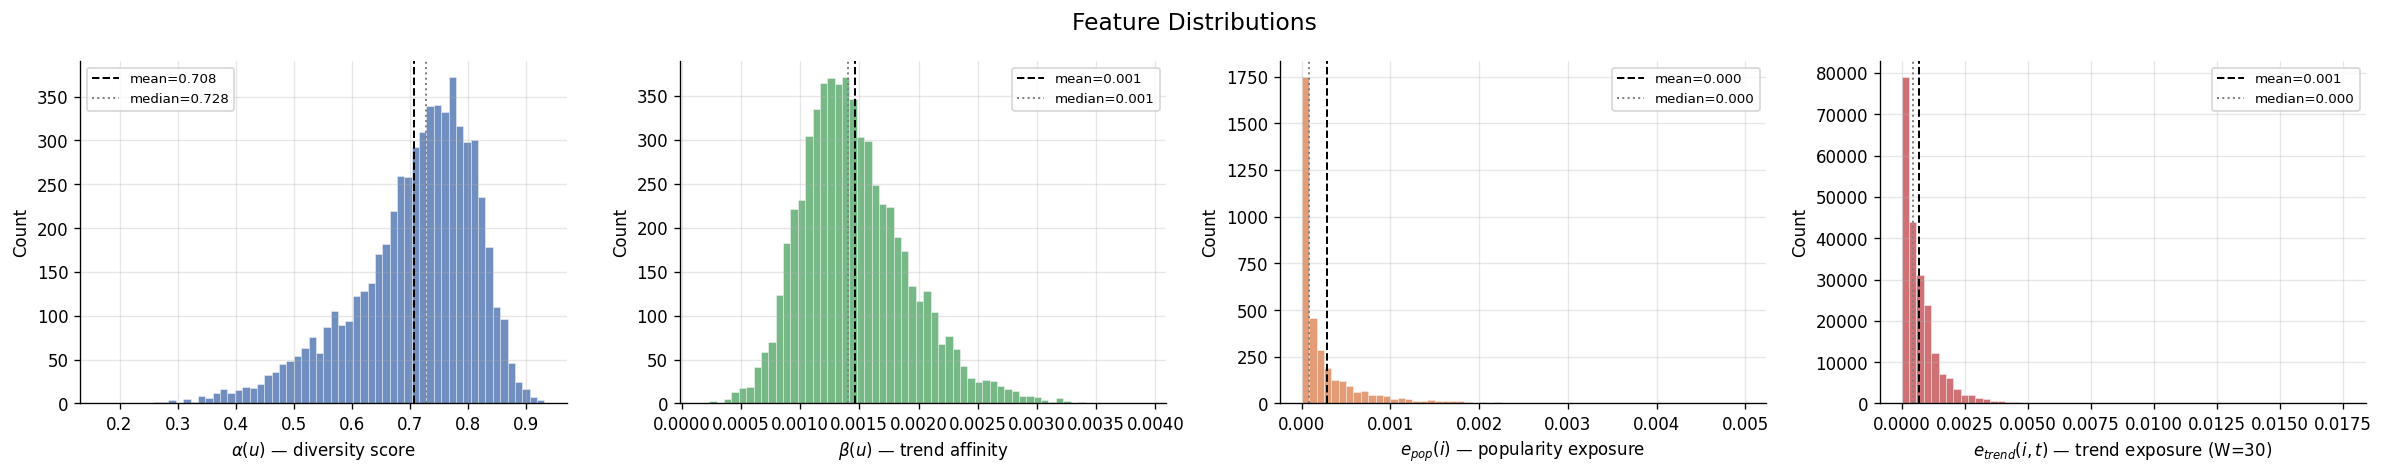

: 

In [ ]:
# Histograms for each feature
HIST_CONFIG = {
    "alpha":   ("#4C72B0", r"$\alpha(u)$ — diversity score"),
    "beta":    ("#55A868", r"$\beta(u)$ — trend affinity"),
    "e_pop":   ("#DD8452", "$e_{pop}(i)$ — popularity exposure"),
    "e_trend": ("#C44E52", f"$e_{{trend}}(i, t)$ — trend exposure (W={WINDOW})"),
}

n = len(feature_values)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, (name, vals) in zip(axes, feature_values.items()):
    color, xlabel = HIST_CONFIG.get(name, (DEFAULT_COLOR, name))
    ax.hist(vals, bins=60, color=color, alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(vals.mean(),   color="black",  linestyle="--", linewidth=1.2, label=f"mean={vals.mean():.3f}")
    ax.axvline(np.median(vals), color="gray", linestyle=":",  linewidth=1.2, label=f"median={np.median(vals):.3f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()